# Event-Based Machine-Learning Trading: Assignment Showcase

**Toy implementation of the main codebase:** [crowleymr/event_based_ml_trading_algo](https://github.com/crowleymr/event_based_ml_trading_algo)  
**32513 Advanced Data Analytics Algorithms (Machine Learning)**  
**Executable research notebook | publication-ready evidence narrative**

**Canonical run:** `20260928T005423Z-0634efaf`  
**Pinned source revision:** `e9b3e0cdf57c63c87a9dc881d58b1696f0472ba5`  
**Claim status:** exploratory close-out, not confirmatory  
**Holdout role:** descriptive only

This notebook is a small educational showcase of the main repository. It demonstrates the implemented weekly cross-sectional equity-ranking system, connects its theory to repository code, verifies a bounded fresh run through the authoritative pipeline, and reads the immutable expanded evidence through the hash-verifying loader. It never uses the completed holdout to select, tune, reject or promote a model.

> **Evidence notice:** values, tables and charts in this notebook are generated from verified artefacts. The bounded smoke run is software verification, not new research evidence. The full expanded evidence remains exploratory and descriptive.

## Contents

1. [How to run this notebook](#how-to-run-this-notebook)
2. [Research problem and task interface](#research-problem-and-task-interface)
3. [Architecture and data lineage](#architecture-and-data-lineage)
4. [Data and leakage controls](#data-and-leakage-controls)
5. [Theory-to-code model walkthrough](#theory-to-code-model-walkthrough)
6. [Validation and HPO](#validation-and-hpo)
7. [Fresh executable demonstration](#fresh-executable-demonstration)
8. [Canonical results](#canonical-results)
9. [Interpretation and limitations](#interpretation-and-limitations)
10. [References](#references)
11. [Reproducibility and evidence index](#reproducibility-and-evidence-index)

## How to run this notebook

Run all cells from top to bottom. The first code cell installs the notebook dependencies, clones the pinned public source revision when no checkout is present, and downloads/extracts the pinned release evidence bundle. The bounded `configs/smoke.yaml` demonstration uses synthetic data and does not require market-data credentials. The optional full-study route is disabled because it requires the approved protocol, substantial CPU/GPU time, the correct data vintage and a new holdout-governance decision.

The notebook also works from an existing local checkout. In Colab, the warmup cell uses the public GitHub repository and release ZIP by default; set `TRADING_PUBLIC_REPOSITORY_URL`, `TRADING_PUBLIC_REVISION`, or `TRADING_EVIDENCE_URL` only when using a different published revision or evidence bundle.

[Back to contents](#contents)

In [16]:
%pip install -q \
    "polars>=1.30,<2" \
    "duckdb>=1.2,<2" \
    "pyarrow>=19" \
    "scikit-learn>=1.6,<2" \
    "scipy>=1.13,<2" \
    "yfinance>=0.2.65,<1" \
    "requests>=2.32" \
    "PyYAML>=6" \
    "matplotlib>=3.9" \
    "matplotlib-inline>=0.1" \
    "joblib>=1.4" \
    "psutil>=5.9,<8" \
    "xgboost>=3.1,<4" \
    "jupyterlab>=4.3,<5" \
    "nbconvert>=7.16,<8" \
    "ipykernel>=6.29,<7"

print("Colab dependencies installed before repository imports.")

Note: you may need to restart the kernel to use updated packages.
Colab dependencies installed before repository imports.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: d:\repos\event_based_ml_trading_algo\.venv\Scripts\python.exe -m pip install --upgrade pip


In [18]:
from pathlib import Path
import hashlib
import json
import os
import subprocess
import sys
import urllib.request
import zipfile
from datetime import datetime, timezone

LOAD_CANONICAL_EVIDENCE = True
RUN_FRESH_DEMO = True
RUN_FULL_EXPANDED_STUDY = False
CANONICAL_RUN_ID = "20260928T005423Z-0634efaf"
CANONICAL_REVISION = "e9b3e0cdf57c63c87a9dc881d58b1696f0472ba5"
PUBLIC_REPOSITORY_URL = os.environ.get(
    "TRADING_PUBLIC_REPOSITORY_URL",
    "https://github.com/crowleymr/event_based_ml_trading_algo.git",
)
PUBLIC_REVISION = os.environ.get("TRADING_PUBLIC_REVISION", CANONICAL_REVISION)
EVIDENCE_URL = os.environ.get(
    "TRADING_EVIDENCE_URL",
    "https://raw.githubusercontent.com/crowleymr/event_based_ml_trading_algo/main/"
    "release/assignment-evidence-20260928T005423Z-0634efaf.zip",
)
EVIDENCE_ZIP = Path("/tmp") / "assignment-evidence.zip"
CANONICAL_REPORT_RELATIVE = Path("reports/expanded_closeout") / CANONICAL_RUN_ID
OUTPUT_RELATIVE = Path("reports/notebook_outputs/final-assignment-showcase-v1")


def find_repository(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src" / "trading_pipeline").is_dir():
            return candidate
    return None


root = find_repository()
if root is None:
    checkout = Path.cwd() / "event_based_ml_trading_algo"
    subprocess.run(["git", "clone", PUBLIC_REPOSITORY_URL, str(checkout)], check=True)
    subprocess.run(["git", "-C", str(checkout), "checkout", PUBLIC_REVISION], check=True)
    root = checkout

os.chdir(root)
if RUN_FULL_EXPANDED_STUDY:
    raise RuntimeError("Full expanded study execution is disabled in this showcase; use the approved study runner and a new holdout protocol.")
evidence_manifest = root / CANONICAL_REPORT_RELATIVE / "research_evidence_manifest.json"
if not evidence_manifest.is_file():
    print(f"Downloading pinned evidence bundle from {EVIDENCE_URL}")
    urllib.request.urlretrieve(EVIDENCE_URL, EVIDENCE_ZIP)
    with zipfile.ZipFile(EVIDENCE_ZIP) as bundle:
        bundle.extractall(root)
    EVIDENCE_ZIP.unlink(missing_ok=True)
print({
    "repository": str(root),
    "revision": PUBLIC_REVISION if root.name == "event_based_ml_trading_algo" else "local checkout",
    "python": Path(sys.executable).name,
    "load_canonical": LOAD_CANONICAL_EVIDENCE,
    "run_fresh_demo": RUN_FRESH_DEMO,
    "run_full_expanded_study": RUN_FULL_EXPANDED_STUDY,
})

{'repository': 'D:\\repos\\event_based_ml_trading_algo', 'revision': 'e9b3e0cdf57c63c87a9dc881d58b1696f0472ba5', 'python': 'python.exe', 'load_canonical': True, 'run_fresh_demo': True, 'run_full_expanded_study': False}


In [13]:
import polars as pl
from IPython.display import Markdown, display
from trading_pipeline.dashboard.loader import load_expanded_report


def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

report_dir = (root / CANONICAL_REPORT_RELATIVE).resolve()
manifest_path = report_dir / "research_evidence_manifest.json"
if LOAD_CANONICAL_EVIDENCE:
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Canonical evidence is unavailable: {manifest_path}")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("source_run_id") != CANONICAL_RUN_ID:
        raise ValueError("Canonical run ID does not match the evidence manifest")
    if manifest.get("code_version") != CANONICAL_REVISION:
        raise ValueError("Canonical source revision does not match the evidence manifest")
    canonical = load_expanded_report(report_dir)
    tables = canonical["tables"]
    provenance = canonical["provenance"]
    expected_tables = {
        "pipeline_stage_summary", "pipeline_security_summary", "architecture_trial_summary",
        "hpo_trial_summary", "risk_scenario_summary", "model_conditioned_frontier_points",
        "model_conditioned_frontier_weights", "realised_risk_return_curve",
        "final_testbench_metrics", "final_testbench_equity_curve", "question_and_assumption_register",
    }
    if set(tables) != expected_tables:
        raise ValueError(f"Unexpected canonical table inventory: {sorted(tables)}")
    display(Markdown(
        f"**Verified canonical evidence**  \n"
        f"Run: `{provenance['source_run_id']}`  \n"
        f"Revision: `{provenance['code_version']}`  \n"
        f"Manifest SHA-256: `{sha256(manifest_path)}`  \n"
        f"Tables: `{len(tables)}`  \n"
        f"Status: `{provenance['claim_status']}`"
    ))
else:
    tables = {}
    provenance = {}
    display(Markdown("Canonical evidence loading is disabled."))

**Verified canonical evidence**  
Run: `20260928T005423Z-0634efaf`  
Revision: `e9b3e0cdf57c63c87a9dc881d58b1696f0472ba5`  
Manifest SHA-256: `4144c9d1bd0c1637eb83021edd7d5359255aa56e73e13e49c5cd1f1d5fd1190a`  
Tables: `11`  
Status: `exploratory_closeout_not_confirmatory`

## 1. Research problem and task interface

The task is **five-trading-day cross-sectional equity ranking**. At a decision date T, the system uses market history and SEC facts available through T to score securities. The supervised label is

$$y_{i,T}=\frac{P_{i,T+5}}{P_{i,T}}-1,$$

where the future return is label-only. A signal is generated after T and implemented at the next observed session's close, T+1. Weekly rebalancing, explicit transaction costs and cash-aware risk scenarios convert a score into an economic decision. SPY is the passive US-equity benchmark.

The supervised interface emits a real-valued score for each eligible security; the portfolio layer ranks those scores. DQN and PPO emit a discrete action over frozen portfolio sleeves rather than individual shares:

`CASH`, `E0` momentum, `E1` Elastic Net, `E2` histogram boosting, `E3` XGBoost, `E4` fixed ensemble, and `E5` inverse-volatility-weighted E4.

This notebook separates locked Slice 1 evidence, expanded exploratory work and descriptive holdout evidence. The completed holdout is not a model-selection device.

[Back to contents](#contents)

## 2. Architecture and data lineage

![Native ETL and point-in-time information controls](assets/native_etl_information_controls.png)

**Figure 1.** Native figure extracted from the assignment DOCX: public sources, identifier mapping and information-availability controls. The corresponding repository components are [the data pipeline](../src/trading_pipeline/data/pipeline.py), [security master](../src/trading_pipeline/data/security_master.py), [PIT features](../src/trading_pipeline/features/build.py), and [audit](../src/trading_pipeline/validation/leakage.py).

![Native feature, label and execution timeline](assets/native_feature_label_execution_timeline.png)

**Figure 2.** Native figure extracted from the assignment DOCX: backward-looking features, the forward label and next-session execution. See [market features](../src/trading_pipeline/features/market.py), [fundamentals](../src/trading_pipeline/features/fundamentals.py), [targets](../src/trading_pipeline/modelling/targets.py), and [temporal splits](../src/trading_pipeline/modelling/splits.py).

![Native shared research architecture](assets/native_shared_research_architecture.png)

**Figure 3.** Native figure extracted from the assignment DOCX: shared data/evaluation with supervised and RL decision branches. The authoritative execution path is [trading_pipeline.run](../src/trading_pipeline/run.py), with [portfolio accounting](../src/trading_pipeline/portfolio/backtest.py) producing the reconciled economic outputs.

[Back to contents](#contents)

In [3]:
from trading_pipeline.config import load_config
from trading_pipeline.modelling.training import MATRIX

config = load_config(root / "configs" / "smoke.yaml")
print("Smoke configuration:")
print(json.dumps({k: v for k, v in config.items() if k not in {"sec_user_agent"}}, indent=2, default=str))
print("\nRegistered model matrix:")
print(json.dumps(MATRIX, indent=2, default=str))

source_links = {
    "Elastic Net": "src/trading_pipeline/modelling/supervised_models/elastic_net.py",
    "HistGradientBoosting": "src/trading_pipeline/modelling/supervised_models/hist_gbt.py",
    "XGBoost": "src/trading_pipeline/modelling/supervised_models/xgboost.py",
    "LSTM / causal Transformer": "src/trading_pipeline/modelling/supervised_models/deep_sequence.py",
    "DQN / PPO": "src/trading_pipeline/rl/policy_models",
    "Portfolio and costs": "src/trading_pipeline/portfolio/backtest.py",
}
for family, path in source_links.items():
    print(f"{family}: {path}")

Smoke configuration:
{
  "mode": "synthetic",
  "data_dir": "data/smoke",
  "runs_dir": "runs/smoke",
  "universe": "configs/universe.txt",
  "start": "2015-01-01",
  "end": "2026-09-12",
  "horizon": 5,
  "cost_bps": 10,
  "top_k": 10,
  "seed": 42,
  "synthetic_sessions": 650,
  "synthetic_securities": 12,
  "xgboost": {
    "enabled": true,
    "device": "auto",
    "n_estimators": 40,
    "learning_rate": 0.05,
    "early_stopping_rounds": 5,
    "device_benchmark": true,
    "research_status": "software_verification_only"
  },
  "research_status": "software_verification_only"
}

Registered model matrix:
{
  "E1": [
    "F0",
    "elastic_net"
  ],
  "E2": [
    "F0",
    "gbt"
  ],
  "E3": [
    "F1",
    "elastic_net"
  ],
  "E4": [
    "F1",
    "gbt"
  ],
  "E6": [
    "F0",
    "xgboost"
  ],
  "E7": [
    "F1",
    "xgboost"
  ]
}
Elastic Net: src/trading_pipeline/modelling/supervised_models/elastic_net.py
HistGradientBoosting: src/trading_pipeline/modelling/supervised_models

## 3. Data and leakage controls

Yahoo Finance supplies historical OHLCV and adjusted prices; SEC Company Facts supplies filed EPS and net-income facts. The identifier path is `ticker -> CIK -> stable security_id`; company names are never the join key. A filing is eligible only on a market session strictly after its filed date. Rolling market features use history through T, and the five-session target is constructed only after that boundary.

The temporal protocol uses chronological train, validation and holdout partitions. Purge removes rows whose label interval crosses a later boundary; embargo withholds the first five sessions after a boundary; stopping windows are separate from scoring windows. This protects information flow but does not remove survivorship, vendor-vintage or small-sample limitations.

[Back to contents](#contents)

In [4]:
stage = tables.get("pipeline_stage_summary")
if stage is not None:
    display(stage.sort("stage"))

if stage is not None and "count" in stage.columns:
    import matplotlib.pyplot as plt
    from matplotlib_inline.backend_inline import set_matplotlib_formats

    set_matplotlib_formats("png")
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
    stage_plot = stage.sort("count", descending=True)
    ax.bar(stage_plot["stage"].to_list(), stage_plot["count"].to_list(), color="#1f6f78")
    ax.set_title(f"Canonical pipeline coverage | run {CANONICAL_RUN_ID}")
    ax.set_xlabel("Pipeline stage")
    ax.set_ylabel("Count (stage-declared unit)")
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

print("Point-in-time implementation:", "src/trading_pipeline/features/fundamentals.py")
print("Temporal split implementation:", "src/trading_pipeline/modelling/splits.py")

stage,count,count_unit,partition
str,i64,str,str
"""feature_ready""",29015,"""security_sessions""","""descriptive_holdout"""
"""fundamental_covered""",29015,"""security_sessions""","""descriptive_holdout"""
"""held""",1946,"""security_sessions""","""descriptive_holdout"""
"""labelled""",29760,"""security_sessions""","""descriptive_holdout"""
"""mapped""",497,"""securities""","""descriptive_holdout"""
"""predicted""",29760,"""security_sessions""","""descriptive_holdout"""
"""priced""",29760,"""security_sessions""","""descriptive_holdout"""
"""requested""",500,"""securities""","""descriptive_holdout"""


<Figure size 1200x600 with 1 Axes>

Point-in-time implementation: src/trading_pipeline/features/fundamentals.py
Temporal split implementation: src/trading_pipeline/modelling/splits.py


## 4. Theory-to-code model walkthrough

### Supervised scores

The supervised families estimate a five-session return score. Elastic Net minimises a squared-error objective with L1/L2 regularisation:

$$\frac{1}{2n}\sum_i(y_i-\hat y_i)^2+\alpha\rho\|\beta\|_1+\frac{\alpha(1-\rho)}{2}\|\beta\|_2^2.$$

Histogram gradient boosting and XGBoost build additive trees that correct residuals. Their inputs are tabular feature rows of shape `(n_observations, n_features)` and their output is `(n_observations,)`. See the registered implementations in the [supervised model package](../src/trading_pipeline/modelling/supervised_models).

![Native LSTM supervised interface](assets/native_lstm_supervised_interface.png)

**Figure 4.** Native LSTM figure extracted from the assignment DOCX. It shows historical features, masking, gated memory and a supervised return head. The sequence input has shape `(batch, lookback, features)` and emits one scalar score per current row.

![Native Transformer supervised interface](assets/native_transformer_supervised_interface.png)

**Figure 5.** Native causal Transformer figure extracted from the assignment DOCX. Causal masking prevents later positions entering the representation, but cannot repair future information already present in an input.

### Policy actions

DQN estimates action values with a temporal-difference target; PPO learns a clipped actor-critic objective. Both act over the seven frozen sleeves listed above, not directly over 100 individual securities. The environment records T+1 execution, weekly endpoint valuation, turnover and after-cost reward.

![Native DQN policy interface](assets/native_dqn_policy_interface.png)

**Figure 6.** Native DQN figure extracted from the assignment DOCX. Replay and target networks stabilise optimisation but do not create new market regimes.

![Native PPO policy interface](assets/native_ppo_policy_interface.png)

**Figure 7.** Native PPO figure extracted from the assignment DOCX. The actor selects a frozen sleeve while the critic estimates state value. DQN is sensitive to replay and simulator dependence; PPO is sensitive to on-policy sample efficiency and reward design.

The repository registrations are visible in [RL policies](../src/trading_pipeline/rl/policy_models), [the RL environment](../src/trading_pipeline/rl/environment.py), and [the experiment registry](../src/trading_pipeline/experiments/registry.py). The exact fitted expanded components and parameters are evidence, not a reason to claim that one architecture is intrinsically superior.

[Back to contents](#contents)

## 5. Validation and HPO

Nested purged expanding walk-forward validation keeps inner folds for family-local candidate comparison and outer folds for procedure-level estimation. HPO is compared within model families because candidate objectives, input shapes and economic interfaces differ. Supervised settings use Spearman IC as the declared ranking objective with error metrics as diagnostics; RL settings use weekly net certainty-equivalent reward within each risk scenario. Sharpe ratio evaluates economic outcomes and does not replace the declared selection criterion.

![Native nested HPO and holdout protocol](assets/native_nested_hpo_holdout.png)

**Figure 8.** Native nested HPO figure extracted from the assignment DOCX. Candidate settings are compared within family, locks precede the descriptive holdout, and the holdout cannot select a model.

The key distinction is:

$$\text{minimise point forecast error} \ne \text{maximise rank quality} \ne \text{maximise after-cost wealth}.$$

MAE and RMSE are return-unit errors. Spearman IC is cross-sectional rank correlation. Sharpe is annualised mean net return divided by volatility under the report convention. Drawdown is peak-to-trough loss; turnover is absolute traded value divided by pre-trade equity; transaction costs are charged on actual traded dollars. The completed holdout is descriptive only, and controlled sensitivity contrasts are selection-ineligible.

[Back to contents](#contents)

## 6. Fresh executable demonstration

The next code cell invokes the authoritative `trading_pipeline.run` CLI with `configs/smoke.yaml`, discovers the newly created run directory, audits it, and compares only artefact structure with the canonical study. The demonstration is synthetic software verification and must not be presented as reproducing the expanded research.

In [5]:
import time
from trading_pipeline.validation.leakage import audit

before = {p.name for p in (root / "runs" / "smoke").glob("*") if p.is_dir()} if RUN_FRESH_DEMO else set()
if RUN_FRESH_DEMO:
    started = time.perf_counter()
    subprocess.run(
        [sys.executable, "-m", "trading_pipeline.run", "--config", "configs/smoke.yaml"],
        cwd=root,
        check=True,
    )
    elapsed = time.perf_counter() - started
    candidates = [p for p in (root / "runs" / "smoke").glob("*") if p.is_dir() and p.name not in before]
    if not candidates:
        raise RuntimeError("Smoke CLI completed but no new run directory was discovered")
    fresh_run = max(candidates, key=lambda p: p.stat().st_mtime)
    fresh_audit = audit(fresh_run)
    if not fresh_audit.get("passed"):
        raise RuntimeError(f"Fresh smoke audit failed: {fresh_audit}")
    fresh_inventory = sorted(p.relative_to(fresh_run).as_posix() for p in fresh_run.rglob("*") if p.is_file())
    fresh_metadata = json.loads((fresh_run / "metadata.json").read_text(encoding="utf-8"))
    print(json.dumps({
        "run_id": fresh_run.name,
        "elapsed_seconds": round(elapsed, 2),
        "audit": fresh_audit,
        "execution": fresh_metadata.get("execution"),
        "cost_bps_one_way": fresh_metadata.get("cost_bps_one_way"),
        "artefact_count": len(fresh_inventory),
        "sample_artefacts": fresh_inventory[:12],
    }, indent=2, default=str))
    fresh_comparison = pl.read_parquet(fresh_run / "experiment_comparison.parquet")
    display(fresh_comparison.head(8))
else:
    fresh_run = None
    display(Markdown("Fresh demonstration disabled by configuration."))

print("This run verifies software wiring and auditability; it is not expanded-study evidence.")

{
  "run_id": "20261001T061915Z-e92eaf32",
  "elapsed_seconds": 11.0,
  "audit": {
    "checks": {
      "raw_hashes": true,
      "snapshot_hashes": true,
      "feature_hash": true,
      "strict_filing_availability": true,
      "prediction_unique_keys": true,
      "prediction_finite": true,
      "long_only": true,
      "weights_at_most_one": true,
      "cash_nonnegative": true,
      "exact_next_session_execution": true,
      "train_purge": true,
      "validation_purge": true,
      "e5_identical_predictions": true,
      "e5_same_top_k": true,
      "trade_costs": true,
      "cost_reconciliation": true,
      "equity_return_reconciliation": true
    },
    "passed": true,
    "check_count": 17,
    "note": "Integrity audit only; no performance-driven decisions."
  },
  "execution": "first session of ISO week signal after close T, fill T+1 close",
  "cost_bps_one_way": 10,
  "artefact_count": 33,
  "sample_artefacts": [
    "audit.json",
    "config.yaml",
    "daily_ic.parq

experiment,split,total_return,annualised_return,annualised_volatility,sharpe,maximum_drawdown,average_turnover,total_turnover,cumulative_transaction_cost,sessions,mae,rmse,mean_ic,ic_dates
str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64
"""E0""","""validation""",0.022847,0.050298,0.058741,0.86462,-0.018691,0.048298,5.602577,0.005653,116,0.046986,0.058482,-0.049192,116
"""E1""","""validation""",0.029976,0.066267,0.058273,1.130104,-0.014738,0.065267,7.570964,0.007659,116,0.021243,0.026256,-0.100675,116
"""E2""","""validation""",0.056692,0.127266,0.058113,2.090678,-0.014026,0.053495,6.205425,0.00639,116,0.021616,0.026828,-0.025681,116
"""E3""","""validation""",0.014013,0.030693,0.056466,0.563416,-0.022159,0.063617,7.37952,0.007388,116,0.021252,0.02623,-0.076742,116
"""E4""","""validation""",0.018296,0.040172,0.055625,0.73567,-0.015127,0.053563,6.213308,0.006267,116,0.021352,0.026549,0.05299,116
"""E6""","""validation""",0.040893,0.09097,0.057279,1.548696,-0.015999,0.038261,4.438264,0.004505,116,0.020889,0.025873,0.008316,116
"""E7""","""validation""",0.061743,0.139002,0.056614,2.327565,-0.014664,0.050231,5.82682,0.006008,116,0.020778,0.025723,0.071884,116
"""E5""","""validation""",0.004131,0.008995,0.056172,0.187244,-0.019365,0.068756,7.975695,0.008016,116,0.021352,0.026549,0.05299,116


This run verifies software wiring and auditability; it is not expanded-study evidence.


## 7. Canonical results

The following figures and table are generated from the hash-verified canonical expanded report. They are descriptive views of the predeclared model-by-risk matrix. The after-cost equity path answers **when** outcomes diverged; the risk-return view answers **how** terminal outcomes trade against realised variability. Neither view creates a new winner.

The comparative table uses the pre-holdout `selected_global` locks as the definition of each model's selected or "best" configuration, then reports that locked model on the descriptive final evaluation sample across all risk scenarios. It includes return, volatility, conventional Sharpe, maximum drawdown, turnover, transaction costs and benchmark-relative return. `downside_sharpe` is a notebook-derived Sortino-style ratio: annualised mean period return divided by annualised downside deviation, where only negative period returns contribute to downside deviation. It is descriptive and selection-ineligible.

[Back to contents](#contents)

model_id,risk_scenario,split,total_return,annualised_volatility,sharpe,maximum_drawdown,average_turnover,cumulative_transaction_cost,benchmark_total_return
str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B0_SPY""","""benchmark""","""descriptive_holdout""",0.042702,0.088208,2.097926,-0.016226,0.083333,0.001,0.042702
"""DQN_SELECTOR""","""aggressive""","""descriptive_holdout""",-0.054477,0.097341,-2.443436,-0.067634,0.198342,0.002293,0.042702
"""DQN_SELECTOR""","""balanced""","""descriptive_holdout""",-0.002505,0.072756,-0.116052,-0.028718,0.165429,0.001972,0.042702
"""DQN_SELECTOR""","""conservative""","""descriptive_holdout""",-0.003379,0.045363,-0.302598,-0.018846,0.128082,0.001533,0.042702
"""EN_F1_STACK""","""aggressive""","""descriptive_holdout""",-0.005829,0.088118,-0.246999,-0.035904,0.11042,0.00133,0.042702
"""EN_F1_STACK""","""balanced""","""descriptive_holdout""",-0.003795,0.06703,-0.215012,-0.027214,0.090768,0.001093,0.042702
"""EN_F1_STACK""","""conservative""","""descriptive_holdout""",-0.002706,0.044117,-0.245893,-0.018054,0.055305,0.000665,0.042702
"""HGBT_F1_STACK""","""aggressive""","""descriptive_holdout""",0.024797,0.091834,1.198757,-0.024207,0.383658,0.004681,0.042702
"""HGBT_F1_STACK""","""balanced""","""descriptive_holdout""",0.018888,0.069004,1.207416,-0.018174,0.287769,0.003497,0.042702


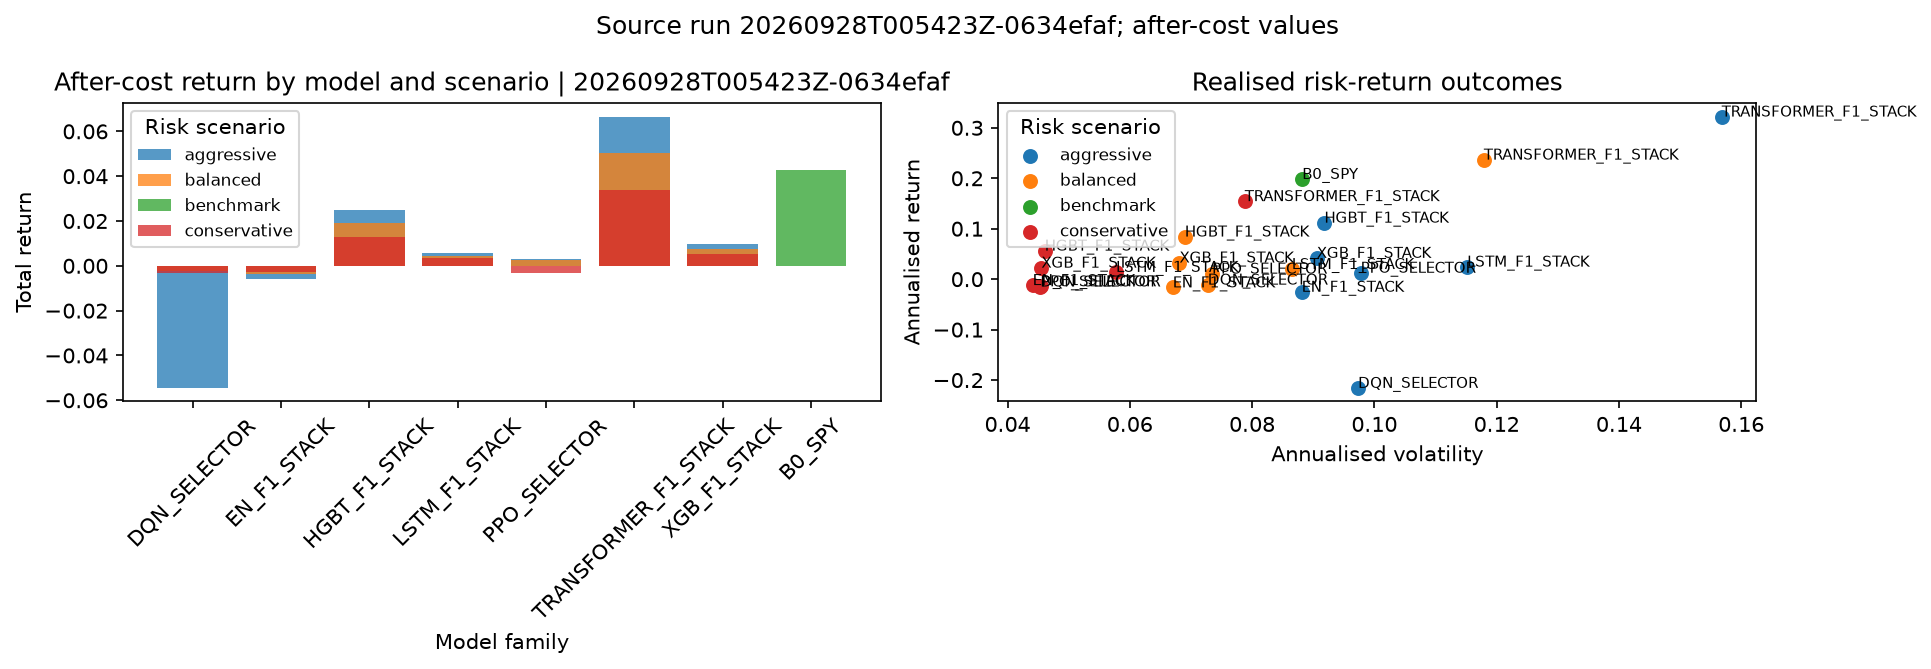

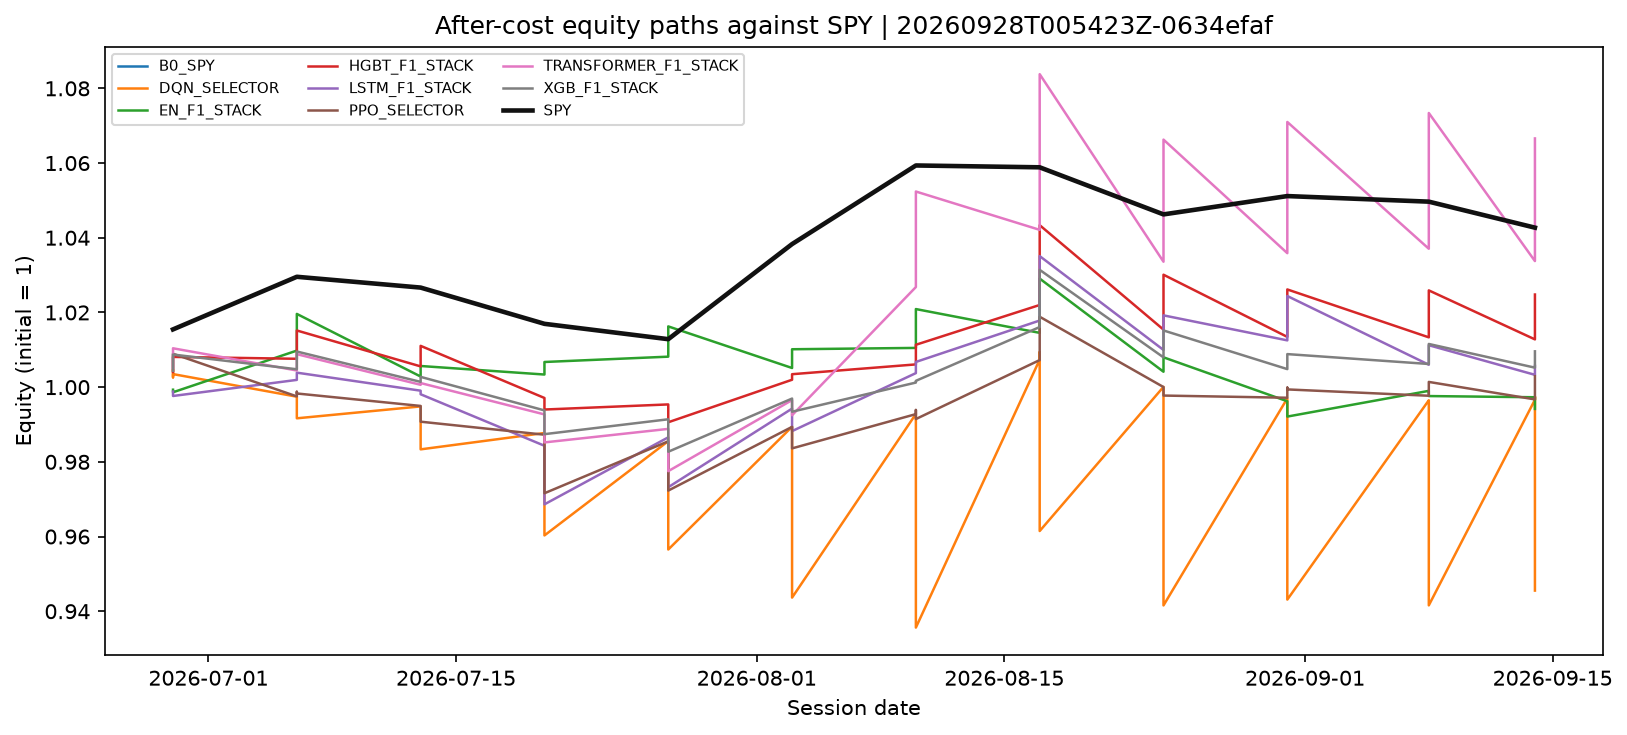

In [15]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")
metrics = tables["final_testbench_metrics"]
summary_columns = [
    "model_id", "risk_scenario", "split", "total_return", "annualised_volatility",
    "sharpe", "maximum_drawdown", "average_turnover", "cumulative_transaction_cost",
    "benchmark_total_return",
]
summary = metrics.select([c for c in summary_columns if c in metrics.columns]).sort(["model_id", "risk_scenario"])
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=-1):
    display(summary.head(21))

plot_metrics = metrics.filter(pl.col("split").is_in(["descriptive_holdout", "test"]))
if plot_metrics.is_empty():
    plot_metrics = metrics
plot_metrics = plot_metrics.sort(["model_id", "risk_scenario"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)
for scenario in plot_metrics["risk_scenario"].unique().sort().to_list():
    cell = plot_metrics.filter(pl.col("risk_scenario") == scenario)
    axes[0].bar(cell["model_id"].to_list(), cell["total_return"].to_list(), alpha=0.75, label=scenario)
axes[0].set_title(f"After-cost return by model and scenario | {CANONICAL_RUN_ID}")
axes[0].set_xlabel("Model family")
axes[0].set_ylabel("Total return")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Risk scenario", fontsize=8)
for scenario in plot_metrics["risk_scenario"].unique().sort().to_list():
    cell = plot_metrics.filter(pl.col("risk_scenario") == scenario)
    axes[1].scatter(cell["annualised_volatility"], cell["annualised_return"], label=scenario, s=38)
    for row in cell.iter_rows(named=True):
        axes[1].annotate(row["model_id"], (row["annualised_volatility"], row["annualised_return"]), fontsize=7)
axes[1].set_title("Realised risk-return outcomes")
axes[1].set_xlabel("Annualised volatility")
axes[1].set_ylabel("Annualised return")
axes[1].legend(title="Risk scenario", fontsize=8)
fig.suptitle(f"Source run {CANONICAL_RUN_ID}; after-cost values")
fig.tight_layout()
display(fig)
plt.close(fig)

curve = tables["final_testbench_equity_curve"]
curve = curve.filter(pl.col("split").is_in(["descriptive_holdout", "test"]))
fig, ax = plt.subplots(figsize=(11, 5), dpi=150)
for label in curve["display_label"].unique().sort().to_list():
    series = curve.filter(pl.col("display_label") == label).sort("session_date")
    ax.plot(series["session_date"].to_list(), series["equity"].to_list(), linewidth=1.2, label=label)
benchmark = curve.select(["session_date", "benchmark_equity"]).unique().sort("session_date")
ax.plot(benchmark["session_date"].to_list(), benchmark["benchmark_equity"].to_list(), color="#111111", linewidth=2.2, label="SPY")
ax.set_title(f"After-cost equity paths against SPY | {CANONICAL_RUN_ID}")
ax.set_xlabel("Session date")
ax.set_ylabel("Equity (initial = 1)")
ax.legend(ncol=3, fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=-1):
    display(tables["hpo_trial_summary"].select([
        c for c in ["model_id", "family", "risk_scenario", "status", "mean_ic", "mean_rmse", "mean_certainty_equivalent", "selected_global"]
        if c in tables["hpo_trial_summary"].columns
    ]).sort(["family", "model_id"]).head(30))

actions = tables["question_and_assumption_register"]
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=-1):
    display(actions.head(12))

# Compare predeclared locked models on the descriptive final evaluation sample.
import numpy as np

locked_models = tables["hpo_trial_summary"].filter(
    pl.col("selected_global") == True
).select(["model_id", "family"]).unique("model_id")
model_labels = pl.concat([
    locked_models,
    pl.DataFrame({"model_id": ["B0_SPY"], "family": ["Benchmark"]}),
]).unique("model_id")
model_ids = model_labels["model_id"].to_list()
comparison = metrics.filter(
    (pl.col("split") == "descriptive_holdout")
    & pl.col("model_id").is_in(model_ids),
).join(model_labels, on="model_id", how="left")
curve_for_comparison = curve.filter(
    (pl.col("split") == "descriptive_holdout")
    & pl.col("model_id").is_in(model_ids),
)
downside_rows = []
for group in curve_for_comparison.partition_by(["model_id", "risk_scenario"], as_dict=False):
    returns = group["period_return"].to_numpy()
    periods = int(comparison.filter(
        (pl.col("model_id") == group["model_id"][0])
        & (pl.col("risk_scenario") == group["risk_scenario"][0]),
    )["periods_per_year"].item())
    downside_deviation = np.sqrt(np.mean(np.minimum(returns, 0.0) ** 2)) * np.sqrt(periods)
    downside_rows.append({
        "model_id": group["model_id"][0],
        "risk_scenario": group["risk_scenario"][0],
        "downside_sharpe": float(np.mean(returns) * periods / downside_deviation)
        if downside_deviation else None,
    })
comparison = comparison.join(
    pl.DataFrame(downside_rows),
    on=["model_id", "risk_scenario"],
    how="left",
)
comparison_columns = [
    "model_id", "family", "risk_scenario", "risk_control_value", "sessions",
    "total_return", "annualised_return", "annualised_volatility", "sharpe",
    "downside_sharpe", "maximum_drawdown", "average_turnover", "total_turnover",
    "cumulative_transaction_cost", "benchmark_total_return",
    "benchmark_relative_total_return",
]
best_model_comparison = comparison.select([
    column for column in comparison_columns if column in comparison.columns
]).sort(["family", "model_id", "risk_scenario"])
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=-1):
    display(best_model_comparison)

output_dir = root / OUTPUT_RELATIVE
output_dir.mkdir(parents=True, exist_ok=True)
summary.write_csv(output_dir / "canonical_metrics.csv")
best_model_comparison.write_csv(output_dir / "best_model_comparison.csv")
with open(output_dir / "README.md", "w", encoding="utf-8") as handle:
    handle.write(f"Generated by final_assignment_showcase.ipynb from run {CANONICAL_RUN_ID} at {datetime.now(timezone.utc).isoformat()}\\n")
    handle.write(f"Source revision: {CANONICAL_REVISION}\\n")
provenance_outputs = {
    path.relative_to(root).as_posix(): sha256(path)
    for path in sorted(output_dir.iterdir()) if path.is_file()
}
(output_dir / "manifest.json").write_text(json.dumps({
    "source_run_id": CANONICAL_RUN_ID,
    "source_report": CANONICAL_REPORT_RELATIVE.as_posix(),
    "source_revision": CANONICAL_REVISION,
    "notebook": "notebooks/final_assignment_showcase.ipynb",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "outputs": provenance_outputs,
}, indent=2), encoding="utf-8")
print(f"Generated evidence outputs: {output_dir.relative_to(root)}")

model_id,family,risk_scenario,status,mean_ic,mean_rmse,mean_certainty_equivalent,selected_global
str,str,str,str,f64,f64,f64,bool
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""aggressive""","""complete""",null,null,0.008273,true
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""aggressive""","""complete""",null,null,0.004272,false
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""aggressive""","""complete""",null,null,0.010463,true
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""aggressive""","""complete""",null,null,0.005004,false
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""balanced""","""complete""",null,null,0.006165,true
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""balanced""","""complete""",null,null,0.003155,false
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""balanced""","""complete""",null,null,0.007031,true
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""balanced""","""complete""",null,null,0.003518,false
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""conservative""","""complete""",null,null,-0.000255,false


item_id,status,kind,fact
str,str,str,str
"""benchmark_availability""","""available""","""generated_limitation""","""SPY was loaded from the protoc…"
"""holdout_role""","""descriptive_only""","""protocol_fact""","""Completed expanded-study holdo…"


model_id,family,risk_scenario,total_return,annualised_return,annualised_volatility,sharpe,downside_sharpe,maximum_drawdown,average_turnover,cumulative_transaction_cost,benchmark_total_return,benchmark_relative_total_return
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""B0_SPY""","""Benchmark""","""benchmark""",0.042702,0.198653,0.088208,2.097926,5.119407,-0.016226,0.083333,0.001,0.042702,0.0
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""aggressive""",-0.054477,-0.215526,0.097341,-2.443436,-2.990812,-0.067634,0.198342,0.002293,0.042702,-0.097179
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""balanced""",-0.002505,-0.010809,0.072756,-0.116052,-0.170816,-0.028718,0.165429,0.001972,0.042702,-0.045206
"""DQN_SELECTOR""","""rl_dqn_sb3_v1""","""conservative""",-0.003379,-0.014562,0.045363,-0.302598,-0.499883,-0.018846,0.128082,0.001533,0.042702,-0.046081
"""PPO_SELECTOR""","""rl_ppo_categorical_sb3_v1""","""aggressive""",0.002922,0.012723,0.097762,0.174073,0.262305,-0.037017,0.224794,0.002691,0.042702,-0.03978
"""PPO_SELECTOR""","""rl_ppo_categorical_sb3_v1""","""balanced""",0.00252,0.010965,0.073456,0.18211,0.27453,-0.027785,0.168762,0.002022,0.042702,-0.040182
"""PPO_SELECTOR""","""rl_ppo_categorical_sb3_v1""","""conservative""",-0.003286,-0.014163,0.045471,-0.292895,-0.479343,-0.018888,0.131362,0.001573,0.042702,-0.045988
"""TRANSFORMER_F1_STACK""","""supervised.causal_transformer.…","""aggressive""",0.066592,0.322288,0.156815,1.856418,5.378619,-0.03256,0.43936,0.00545,0.042702,0.02389
"""TRANSFORMER_F1_STACK""","""supervised.causal_transformer.…","""balanced""",0.05029,0.236915,0.117907,1.860039,5.391751,-0.024433,0.330286,0.004065,0.042702,0.007588


Generated evidence outputs: reports\notebook_outputs\final-assignment-showcase-v1


In [8]:
# Export stable publication-quality chart files without modifying immutable runs.
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=200)
for scenario in plot_metrics["risk_scenario"].unique().sort().to_list():
    cell = plot_metrics.filter(pl.col("risk_scenario") == scenario)
    ax.scatter(cell["annualised_volatility"], cell["annualised_return"], label=scenario, s=45)
    for row in cell.iter_rows(named=True):
        ax.annotate(row["model_id"], (row["annualised_volatility"], row["annualised_return"]), fontsize=7)
ax.set_title(f"Realised risk-return outcomes | source {CANONICAL_RUN_ID}")
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.legend(title="Risk scenario")
fig.tight_layout()
fig.savefig(output_dir / "risk_return.png", bbox_inches="tight")
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 5), dpi=200)
for label in curve["display_label"].unique().sort().to_list():
    series = curve.filter(pl.col("display_label") == label).sort("session_date")
    ax.plot(series["session_date"].to_list(), series["equity"].to_list(), linewidth=1.0, label=label)
ax.plot(benchmark["session_date"].to_list(), benchmark["benchmark_equity"].to_list(), color="#111111", linewidth=2.0, label="SPY")
ax.set_title(f"After-cost equity paths | source {CANONICAL_RUN_ID}")
ax.set_xlabel("Session date")
ax.set_ylabel("Equity (initial = 1)")
ax.legend(ncol=3, fontsize=7)
fig.tight_layout()
fig.savefig(output_dir / "equity_paths.png", bbox_inches="tight")
display(fig)
plt.close(fig)

provenance_outputs = {
    path.relative_to(root).as_posix(): sha256(path)
    for path in sorted(output_dir.iterdir()) if path.is_file() and path.name != "manifest.json"
}
(output_dir / "manifest.json").write_text(json.dumps({
    "source_run_id": CANONICAL_RUN_ID,
    "source_report": CANONICAL_REPORT_RELATIVE.as_posix(),
    "source_revision": CANONICAL_REVISION,
    "notebook": "notebooks/final_assignment_showcase.ipynb",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "outputs": provenance_outputs,
}, indent=2), encoding="utf-8")
print(sorted(provenance_outputs))

['reports/notebook_outputs/final-assignment-showcase-v1/README.md', 'reports/notebook_outputs/final-assignment-showcase-v1/canonical_metrics.csv', 'reports/notebook_outputs/final-assignment-showcase-v1/equity_paths.png', 'reports/notebook_outputs/final-assignment-showcase-v1/risk_return.png']


## 8. Interpretation and limitations

Forecast accuracy, rank quality and investable usefulness are different claims. A model can reduce point error without improving the top-ranked sleeve, and a useful rank signal can be consumed by T+1 execution, turnover, risk scaling or costs. The canonical results therefore report all three layers and retain SPY as the passive opportunity-cost benchmark.

The Transformer’s observed aggressive-scenario outcome should be read cautiously: it may reflect favourable realised selections and exposure scaling during this episode, not intrinsic superiority of attention. The holdout is short, the expanded protocol is exploratory, the sample is non-stationary, and the study lacks CRSP-quality historical constituent and delisting coverage. Inflation, oil-market volatility and the AI/hyperscaler investment boom are plausible regime context, not established causal explanations of any model result.

Other limitations include noisy five-session targets, estimation error, public-data timing and comparability limits, survivorship bias, fixed cost assumptions and single-seed constrained search. Future work requires a fresh data vintage and a new holdout protocol before any feature, model, risk setting or deployment decision is selected.

[STUDENT RESPONSE REQUIRED] Explain one design decision you can now defend independently and one result that challenged your prior expectation.

[STUDENT RESPONSE REQUIRED] State what evidence and risk limits you would require before allowing this educational backtest to influence a financial decision.

[Back to contents](#contents)

## 9. References

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of KDD*. https://doi.org/10.1145/2939672.2939785  
DeMiguel, V., Martín-Utrera, A., Nogales, F. J., & Uppal, R. (2020). A transaction-cost perspective on the multitude of firm characteristics. *The Review of Financial Studies, 33*(5), 2180-2222. https://doi.org/10.1093/rfs/hhz085  
Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *The Annals of Statistics, 29*(5), 1189-1232. https://doi.org/10.1214/aos/1013203451  
Gu, S., Kelly, B., & Xiu, D. (2020). Empirical asset pricing via machine learning. *The Review of Financial Studies, 33*(5), 2223-2273. https://doi.org/10.1093/rfs/hhaa009  
Hambly, B., Xu, R., & Yang, H. (2023). Recent advances in reinforcement learning in finance. *Mathematical Finance, 33*(3), 437-503. https://arxiv.org/abs/2112.04553  
Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735  
López de Prado, M. (2018). *Advances in financial machine learning*. Wiley. https://www.wiley.com/en-us/Advances+in+Financial+Machine+Learning-p-9781119482086  
Mnih, V., et al. (2015). Human-level control through deep reinforcement learning. *Nature, 518*, 529-533. https://doi.org/10.1038/nature14236  
Schulman, J., et al. (2017). Proximal policy optimization algorithms. https://arxiv.org/abs/1707.06347  
Sharpe, W. F. (1994). The Sharpe ratio. *The Journal of Portfolio Management, 21*(1), 49-58. https://web.stanford.edu/~wfsharpe/art/sr/sr.htm  
Vaswani, A., et al. (2017). Attention is all you need. *Advances in Neural Information Processing Systems, 30*. https://arxiv.org/abs/1706.03762  
Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society: Series B, 67*(2), 301-320. https://doi.org/10.1111/j.1467-9868.2005.00503.x

[Back to contents](#contents)

## 10. Reproducibility and evidence index

| Notebook section | Theory/reference | Source code | Configuration | Evidence artefact | Generated figure/table |
|---|---|---|---|---|---|
| Task interface | Gu et al. (2020); Sharpe (1994) | [run.py](../src/trading_pipeline/run.py) | [poc.yaml](../configs/poc.yaml) | canonical manifest | task narrative |
| Data and leakage | López de Prado (2018) | [features](../src/trading_pipeline/features) and [splits.py](../src/trading_pipeline/modelling/splits.py) | expanded protocol | immutable input hashes | pipeline coverage chart |
| Model walkthrough | Friedman (2001); Vaswani et al. (2017); Schulman et al. (2017) | [model packages](../src/trading_pipeline/modelling) and [RL policies](../src/trading_pipeline/rl) | registered study settings | architecture/HPO tables | HPO display |
| Fresh demonstration | software verification | [run.py](../src/trading_pipeline/run.py); [audit](../src/trading_pipeline/validation/leakage.py) | [smoke.yaml](../configs/smoke.yaml) | new `runs/smoke/<run-id>` | inventory and sample output |
| Canonical results | DeMiguel et al. (2020) | [loader.py](../src/trading_pipeline/dashboard/loader.py) | canonical comparison contract | `reports/expanded_closeout/20260928T005423Z-0634efaf` | `reports/notebook_outputs/final-assignment-showcase-v1` |

**Evidence links:** [canonical report manifest](../reports/expanded_closeout/20260928T005423Z-0634efaf/research_evidence_manifest.json) · [canonical source run](../runs/expanded_closeout/20260928T005423Z-0634efaf) · [approved protocol](../configs/studies/expanded_closeout_approved_v5.yaml) · [assignment report](../reports/assignment/20260928T005423Z-0634efaf/v3_concise/PROJECT_REPORT_CONCISE_FINAL.md) · [implementation log](../docs/IMPLEMENTATION_LOG.md)

**Publication fields:** the public repository URL, pinned release tag and release evidence-bundle URL must come from the verified GitHub publication record. This notebook deliberately does not invent them. The current local checkout remains usable without those fields.

[Repository root](../README.md) · [release directory](../release) · [licence](../LICENSE)

[Back to contents](#contents)